In [50]:
import pandas as pd
from pathlib import Path
import yaml

In [51]:
config_file = "../config/uvalde.yaml"
cfg = yaml.safe_load(Path(config_file).read_text(encoding='utf-8')).get('event', {})

In [52]:
# input_file = "../data/event_data/2024_Helene_FL.csv"
# input_file = "../data/event_data/2022_Uvalde_TX.csv"
# input_file = "../data/event_data/2023_Lewiston_MA.csv"
df = pd.read_csv(cfg['input_file'])

In [53]:
import numpy as np
import json
from typing import List, Optional, Tuple


def _parse_emb(s: str) -> Optional[np.ndarray]:
    try:
        arr = np.array(json.loads(s), dtype=np.float32)
        # guard against empty arrays
        if arr.ndim == 1 and arr.size > 0:
            return arr
        return None
    except Exception:
        return None
    
# df['title_emb'] = df['embedding_json_title'].apply(_parse_emb)
# df['first_para_emb'] = df['first_para_emb'].apply(_parse_emb)

In [54]:
# Preprocess/cleanup dataframe
df = df.drop_duplicates(subset=['title', 'text'])

In [57]:
# Make datetime indices and filter dates
df.index = pd.DatetimeIndex(pd.to_datetime(df["date"], format="%Y%m%d"))
df = df.sort_index()
df = df[cfg['start_date']: cfg['end_date']]

# Drop datetime indices
df = df.reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")
df = df.sort_values("date")
dates = df["date"]



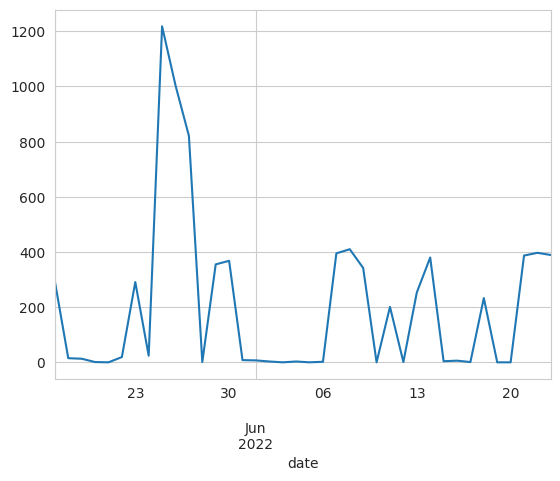

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
articles_per_day = df.resample('1D', on="date")['GlobalEventID'].count().plot();

# sns.scatterplot(data=articles_per_day, x='index', y='count')

In [59]:
# Preprocess text
import spacy
nlp = spacy.load("en_core_web_lg")
stopwords = nlp.Defaults.stop_words


def clean_text_spacy(text):
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if token.is_alpha and token.text not in stopwords]
    return ' '.join(tokens)


def clean_text_regex(texts):
    # Clean up pandas Series
    return texts.str.lower().str.replace(r"[^a-z\s]", "", regex=True).apply(
        lambda x: " ".join([w for w in x.split() if w not in stopwords])
    )


In [60]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer




texts = (df['title'].fillna("") + ". " + df['text'].fillna(""))  # .tolist()
texts = clean_text_regex(texts).tolist()

# load c-TF-IDF
ctfidf_model = ClassTfidfTransformer(
    seed_words = cfg['keywords'],
    seed_multiplier=5
)

# load embeddings
model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(model_name)
embeddings = embedder.encode(texts, batch_size=128, show_progress_bar=True)


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

In [61]:

import hdbscan, umap

umap_model = umap.UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine")
# hdbscan_model = HDBSCAN(min_cluster_size=25, metric="cosine",
#                         cluster_selection_epsilon=0.0)
# WARNING: Use scikit-learn's HDBSCAN will not return `probs` in the right way!

# Note: we will use Euclidean distance with HDBSCAN because the HDBSCAN package does not implement cosine
# However, this is fine because the SentenceTransform embeddings are normalized, hence Euclidean is related to Cosine
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=25, metric="euclidean",
                                cluster_selection_epsilon=0.5,   # Smaller value produces more (and smaller) clusters.
                                cluster_selection_method="eom",
                                prediction_data=True)

topic_model = BERTopic(umap_model=umap_model,
                       hdbscan_model=hdbscan_model,
                       calculate_probabilities=True,
                       verbose=True)

topics, probs = topic_model.fit_transform(texts, embeddings)


2025-12-22 16:36:21,373 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-22 16:36:22,405 - BERTopic - Dimensionality - Completed ✓
2025-12-22 16:36:22,406 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-22 16:36:22,673 - BERTopic - Cluster - Completed ✓
2025-12-22 16:36:22,674 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-22 16:36:23,492 - BERTopic - Representation - Completed ✓


In [62]:
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,614,-1_said_school_texas_shooting,"[said, school, texas, shooting, people, gun, p...",[covid shootings mass death tolerated america ...
1,0,3733,0_school_said_texas_shooting,"[school, said, texas, shooting, gun, uvalde, p...",[texas gunman locked classroom shot students t...
2,1,1470,1_said_texas_new_company,"[said, texas, new, company, like, years, peopl...",[health care hits million covid deaths round f...
3,2,419,2_police_said_county_texas,"[police, said, county, texas, man, found, acco...",[new details emerge convicted murderer texas e...
4,3,379,3_court_border_migrants_texas,"[court, border, migrants, texas, law, supreme,...",[shadow lucia uncertain future sec administrat...
5,4,270,4_nra_orourke_abbott_gun,"[nra, orourke, abbott, gun, texas, convention,...",[gov greg abbott wont plans attend nra convent...
6,5,211,5_notification_notifications_matching_saving,"[notification, notifications, matching, saving...",[church events june notification saved problem...
7,6,150,6_juneteenth_holiday_black_slavery,"[juneteenth, holiday, black, slavery, emancipa...",[new juneteenth holiday gains acceptance slowl...
8,7,145,7_abortion_abortions_roe_pregnancy,"[abortion, abortions, roe, pregnancy, women, s...",[days oklahoma bans abortion details uncertain...
9,8,139,8_settings_javascript_browser_premium,"[settings, javascript, browser, premium, enabl...",[police reports saturday june javascript requi...


In [63]:
hier_topics = topic_model.hierarchical_topics(texts)
fig_h = topic_model.visualize_hierarchy(hierarchical_topics=hier_topics)
fig_h  # Use this to identify adjacent/close topics to merge

100%|██████████| 13/13 [00:00<00:00, 306.22it/s]


In [64]:
### BEGIN MERGING TOPICS

In [65]:
# Calculate overlap in topic words
from sklearn.metrics import pairwise_distances

def topic_top_terms(topic_id, n=10):
    terms = topic_model.get_topic(topic_id)  # list of (term, score)
    return [t[0] for t in terms[:n]]

def jaccard_similarity(a, b):
    sa, sb = set(a), set(b)
    return len(sa & sb) / max(1, len(sa | sb))

def jaccard_distance(a, b):
    ta, tb = topic_top_terms(a), topic_top_terms(b)
    return 1 - jaccard_similarity(ta, tb)

# Get all topics
info = topic_model.get_topic_info()
valid_topics = [t for t in info["Topic"] if t != -1]

d = pairwise_distances(valid_topics, metric=jaccard_distance)
jaccard_sims = 1 - d




In [66]:

from sentence_transformers import util

def topic_rep_embedding(topic_id, embedder, k=10):
    # Get k representative docs for the topic
    rep_docs = topic_model.get_representative_docs(topic_id)[:k]
    emb = embedder.encode(rep_docs, batch_size=64, show_progress_bar=False)
    return emb.mean(axis=0)

# Build an index of topic embeddings
embed_index = {}
info = topic_model.get_topic_info()
valid_topics = [t for t in info["Topic"] if t != -1]
for t in valid_topics:
    embed_index[t] = topic_rep_embedding(t, embedder)

# Cosine similarity matrix
pairs_to_merge = []
for i, ti in enumerate(valid_topics):
    for tj in valid_topics[i+1:]:
        sim = util.cos_sim(embed_index[ti], embed_index[tj]).item()
        if sim >= 0.75:  # threshold you can tune
            pairs_to_merge.append((ti, tj))
# sorted(pairs_to_merge, key=lambda x: -x[2])[:10]


In [67]:
# Reassign outliers
df["topic"] = topics
top_prob = np.max(probs, axis=1)
top_topic = np.argmax(probs, axis=1)

reassign_mask = (df["topic"] == -1)
df.loc[reassign_mask & (top_prob > 0.25), "topic"] = top_topic[reassign_mask & (top_prob > 0.25)]


In [68]:
# Perform merges
topics_to_merge = pairs_to_merge
if len(topics_to_merge) > 0:
    topic_model.merge_topics(texts, topics_to_merge=topics_to_merge)

topic_info = topic_model.get_topic_info()
display(topic_info.head(20))


,Topic,Count,Name,Representation,Representative_Docs
0,-1,614,-1_said_school_texas_shooting,"[said, school, texas, shooting, people, gun, p...",[covid shootings mass death tolerated america ...
1,0,3733,0_school_said_texas_shooting,"[school, said, texas, shooting, gun, uvalde, p...",[texas gunman locked classroom shot students t...
2,1,1470,1_said_texas_new_company,"[said, texas, new, company, like, years, peopl...",[health care hits million covid deaths round f...
3,2,419,2_police_said_county_texas,"[police, said, county, texas, man, found, acco...",[new details emerge convicted murderer texas e...
4,3,379,3_court_border_migrants_texas,"[court, border, migrants, texas, law, supreme,...",[shadow lucia uncertain future sec administrat...
5,4,270,4_nra_orourke_abbott_gun,"[nra, orourke, abbott, gun, texas, convention,...",[gov greg abbott wont plans attend nra convent...
6,5,211,5_notification_notifications_matching_saving,"[notification, notifications, matching, saving...",[church events june notification saved problem...
7,6,150,6_juneteenth_holiday_black_slavery,"[juneteenth, holiday, black, slavery, emancipa...",[new juneteenth holiday gains acceptance slowl...
8,7,145,7_abortion_abortions_roe_pregnancy,"[abortion, abortions, roe, pregnancy, women, s...",[days oklahoma bans abortion details uncertain...
9,8,139,8_settings_javascript_browser_premium,"[settings, javascript, browser, premium, enabl...",[police reports saturday june javascript requi...


In [69]:
# Temporal dynamics

topics_over_time = topic_model.topics_over_time(texts, dates, nr_bins=35)  # ~5 weeks
fig = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=5)
fig

30it [00:03,  8.03it/s]


In [70]:

# Show topic hierarchy after merge

hier_topics = topic_model.hierarchical_topics(texts)
fig_h = topic_model.visualize_hierarchy(hierarchical_topics=hier_topics)
fig_h  


100%|██████████| 13/13 [00:00<00:00, 313.29it/s]


In [71]:
# Find largest topic

topic_info = topic_model.get_topic_info()

# Find the largest topic by size
largest_topic_row = topic_info.loc[topic_info['Count'].idxmax()]
largest_topic_id = largest_topic_row['Topic']
largest_topic_size = largest_topic_row['Count']

print(f"Largest topic ID: {largest_topic_id}, Size: {largest_topic_size}")
print("Top words:", topic_model.get_topic(largest_topic_id))



Largest topic ID: 0, Size: 3733
Top words: [('school', np.float64(0.03294305230448944)), ('said', np.float64(0.028267560811597415)), ('texas', np.float64(0.023126661422395285)), ('shooting', np.float64(0.02266641128211277)), ('gun', np.float64(0.022553786729221523)), ('uvalde', np.float64(0.019586803315000064)), ('police', np.float64(0.016159084555395237)), ('elementary', np.float64(0.014957043563629275)), ('children', np.float64(0.01492654374942514)), ('people', np.float64(0.014501535414121436))]


          dt  n_docs  dist_smooth_to_prev_smooth  dist_raw_to_prev_smooth
0 2022-05-17      58                         NaN                      NaN
1 2022-05-18      10                    0.000687                 0.170359
2 2022-05-19       8                    0.000531                 0.151272
3 2022-05-22      17                    0.000501                 0.131062
4 2022-05-23      94                    0.001083                 0.063793
5 2022-05-24      16                    0.000547                 0.163289
6 2022-05-25     825                    0.007305                 0.118526
7 2022-05-26     628                    0.003350                 0.062115
8 2022-05-27     465                    0.002226                 0.044493
9 2022-05-28       1                    0.001051                 0.188986


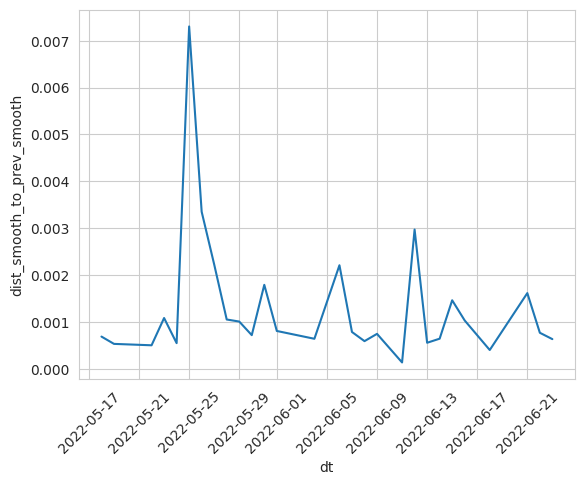

In [118]:
# Retrieve subsets of DataFrame and embeddings
import matplotlib.pyplot as plt
from numpy.linalg import norm


def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = norm(a), norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return 1.0 - float(np.dot(a, b) / (na * nb))



def geometric_median(X, eps=1e-5, max_iter=200):
    # X: (n, d)
    y = X.mean(axis=0)
    for _ in range(max_iter):
        d = np.linalg.norm(X - y, axis=1)
        # Avoid division by zero
        d = np.where(d < eps, eps, d)
        w = 1.0 / d
        y_new = (w[:, None] * X).sum(axis=0) / w.sum()
        if np.linalg.norm(y_new - y) < eps:
            break
        y = y_new
    return y


df = df.copy()
df["row_id"] = np.arange(len(df)) 
# Normalize 'date' to pandas datetime for display
if pd.api.types.is_integer_dtype(df["date"]) or pd.api.types.is_string_dtype(df["date"]):
    df["dt"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
else:
    # If df already has a datetime column, use it
    df["dt"] = pd.to_datetime(df["date"], errors="coerce")
mask = (df["topic"] == largest_topic_id)
# Create row_id column
df_topic = df[mask].copy()
embeddings_topic = embeddings[mask]

topic_2d = umap.UMAP(n_neighbors=10, min_dist=0.1, metric="cosine").fit_transform(embeddings_topic)


## Compute the centroids for each day
centroid_method = "median"  # Can be "mean" or "median" (geometric median)

daily_centroids = []
groups = df_topic.groupby(df_topic["date"])
for gdate, gdf in groups:
    pos_idx = gdf["row_id"].to_numpy()  # Get row positions in original df
    # Find local positions for embeddings
    local_idx = df_topic.index.get_indexer(gdf.index)        # positions within df_topic    
    emb_day = embeddings_topic[local_idx]  # Get embeddings for this date
    if emb_day.size == 0:
        continue
    if centroid_method == "mean":
        centroid_sbert = emb_day.mean(axis=0)  # Compute centroid
    elif centroid_method == "median":
        centroid_sbert = geometric_median(emb_day)
    daily_centroids.append({
        "date_str": gdate,
        "emb": centroid_sbert,
        "n_docs": len(emb_day)
    })


# Convert to DataFrame and sort chronologically
cent_df = pd.DataFrame(daily_centroids)
# Normalize date: if 'date' is an int/string in YYYYMMDD format, convert to datetime
cent_df["dt"] = cent_df['date_str']
cent_df = cent_df.sort_values("dt").reset_index(drop=True)

## BEGIN CENTROID SMOOTHING
#  Exponential Moving Average (EMA) smoothing of centroids (vector EMA)
use_vol_scale = True

vol_scale = np.percentile(cent_df["n_docs"], 75)  # robust target volume
base_alpha = 0.20  # Lower = smoother

ema = []
prev = None
for i, row in cent_df.iterrows():
    c = row["emb"]  # numpy 1D vector
    n = row["n_docs"]
    # Adjust alpha per number of documents on that day / cap at [min_alpha, base_alpha]
    if use_vol_scale:
        adj_alpha = base_alpha * min(1.0, n / vol_scale)
        adj_alpha = max(0.05, adj_alpha)  # avoid freezing on small n
    else:
        adj_alpha = base_alpha

    if prev is None:
        s = c.copy()           # initialize EMA with first day's centroid
    else:
        s = adj_alpha * c + (1.0 - adj_alpha) * prev
    ema.append(s)
    prev = s

cent_df["centroid_ema"] = ema  # attach smoothed centroid


# Distance between consecutive smoothed centroids (main stability signal)
dist_smooth = [np.nan]
for i in range(1, len(cent_df)):
    d = cosine_distance(cent_df.loc[i, "centroid_ema"], cent_df.loc[i-1, "centroid_ema"])
    dist_smooth.append(d)
cent_df["dist_smooth_to_prev_smooth"] = dist_smooth

# Distance between raw centroid and previous day's smoothed centroid (outlier sensitivity)
dist_raw_to_prev_smooth = [np.nan]
for i in range(1, len(cent_df)):
    d = cosine_distance(cent_df.loc[i, "emb"], cent_df.loc[i-1, "centroid_ema"])
    dist_raw_to_prev_smooth.append(d)
cent_df["dist_raw_to_prev_smooth"] = dist_raw_to_prev_smooth

# --- Inspect a few rows ---
print(cent_df[["dt", "n_docs", "dist_smooth_to_prev_smooth", "dist_raw_to_prev_smooth"]].head(10))



    ### Make individual plots per date
    # emb2d = topic_2d[local_idx]         # embeddings for this date within the topic
    # print(emb2d.shape)
    # plt.figure(figsize=(6,5))
    # plt.scatter(emb2d[:,0], emb2d[:,1], s=12, alpha=0.8)
    # plt.title(f"Topic {largest_topic_id} — {gdate}")
    # plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
    # plt.tight_layout(); plt.show()


sns.lineplot(data=cent_df, x='dt', y='dist_smooth_to_prev_smooth');
# sns.lineplot(data=cent_df, x='dt', y='dist_raw_to_prev_smooth');
plt.xticks(rotation=45);



In [ ]:

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

import textwrap


reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, metric="cosine", random_state=42)
topic_2d = reducer.fit_transform(embeddings_topic)

assert topic_2d.shape[0] == len(df_topic), "UMAP output must match topic subset size"

plot_df = df_topic.reset_index(drop=True).copy()
plot_df["umap_x"] = topic_2d[:, 0]
plot_df["umap_y"] = topic_2d[:, 1]

# Shorten text for hover
def short_text(s, width=60):
    if not isinstance(s, str):
        return ""
    s = " ".join(s.split())  # normalize whitespace
    # return textwrap.shorten(s, width=width, placeholder="…")
    return textwrap.wrap(s, width=width, max_lines=2, placeholder="...")

plot_df["hover_text"] = plot_df["text"].apply(lambda s: short_text(s, width=180))
plot_df["hover_title"] = plot_df["title"].apply(lambda s: short_text(s, width=120))
plot_df["date_str"] = plot_df["dt"].dt.strftime("%Y-%m-%d")  # nice format for the animation slider

# You can color by source domain, outlet, or nothing; here we color by domain if present.
color_col = "domain" if "domain" in plot_df.columns else None

centroids_2d_smooth = reducer.transform(np.array(cent_df['centroid_ema'].values.tolist()))
cent_df['centroid_x_sm'] = centroids_2d_smooth[:, 0].tolist()
cent_df['centroid_y_sm'] = centroids_2d_smooth[:, 1].tolist()
# Also plot raw centroid
centroids_2d= reducer.transform(np.array(cent_df['emb'].values.tolist()))
cent_df['centroid_x'] = centroids_2d[:, 0].tolist()
cent_df['centroid_y'] = centroids_2d[:, 1].tolist()

plot_df = plot_df.groupby("date").sample(n=300, replace=True)
ordered_dates = sorted(list(plot_df["date_str"].unique()))

fig = px.scatter(
    plot_df,
    x="umap_x",
    y="umap_y",
    category_orders={"date_str": ordered_dates},
    color=None,                      # set to None to hide
    hover_name="hover_title",
    hover_data={
        "umap_x": False, "umap_y": False, # hide numeric coords in hover
        "date_str": True,
        "SOURCEURL": True,
        "hover_text": True,
    },
    animation_frame="date_str",           # one plot per day via slider
    title=f"Topic {largest_topic_id} — UMAP by Day (hover for title/text/URL)",
    template="plotly_white",
)

## Make the hover prettier: fully control which fields show
fig.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>" +  # uses hover_name
                  "Date: %{customdata[0]}<br>" +
                  "<extra></extra>"
)

# Or use a more explicit hovertemplate with multiple fields (override above):
# Note: when using 'hover_data' dict, Plotly packs them in order; alternatively, build a custom column.
# Here's a robust custom hover using "text" + "customdata" for full control:
custom_hover = (
    "Title: %{customdata[0]}<br>" +
    "Date: %{customdata[1]}<br>" +
    "URL: %{customdata[2]}<br><br>" +
    "%{customdata[3]}"
)

fig.update_traces(
    text=plot_df["hover_title"],  # fallback
    customdata=np.stack([
        plot_df["hover_title"],
        plot_df["date_str"],
        plot_df["SOURCEURL"].fillna(""),
        plot_df["hover_text"]
    ], axis=1),
    hovertemplate=custom_hover
)


# --- Add centroid markers to each frame ---
# Build centroid-only frames and merge into the existing frames by name
centroid_frames = []
for d in ordered_dates:
    cdf = cent_df[cent_df["date_str"] == d]
    centroid_frames.append(go.Frame(
        name=d,
        data=[go.Scatter(
            x=cdf["centroid_x"],
            y=cdf["centroid_y"],
            mode="markers",
            marker=dict(size=12, symbol="x", color="red", line=dict(width=1, color="yellow")),
            name="Centroid (raw)",
            hovertemplate="<b>Raw centroid</b><br>Date: %{x|}<br><extra>n_docs: %{text}</extra>",
            text=cdf["n_docs"]
        ),
        go.Scatter(
            x=cdf["centroid_x_sm"],
            y=cdf["centroid_y_sm"],
            mode="markers",
            marker=dict(size=12, symbol="circle", color="black", line=dict(width=1, color="yellow")),
            name="Centroid (smoothed)",
            hovertemplate="<b>Smoothed centroid</b><br>Date: %{x|}<br><extra>n_docs: %{text}</extra>",
            text=cdf["n_docs"]
        )
        ]
    ))


# Need to call "add_trace" or marker will not appear!
if ordered_dates:
    first_date = ordered_dates[0]
    c0 = cent_df[cent_df["date_str"] == first_date]
    if not c0.empty:
        fig.add_trace(go.Scatter(
            x=c0["centroid_x"], y=c0["centroid_y"],
            mode="markers",
            marker=dict(size=12, symbol="x", color="red", line=dict(width=1, color="yellow")),
            name="Raw centroid",
            hovertemplate="<b>Raw centroid</b><br><extra>n_docs: %{text}</extra>",
            text=c0["n_docs"]
        ))
        fig.add_trace(go.Scatter(
            x=c0["centroid_x_sm"], y=c0["centroid_y_sm"],
            mode="markers",
            marker=dict(size=12, symbol="circle", color="black", line=dict(width=1, color="yellow")),
            name="Smoothed centroid",
            hovertemplate="<b>Smoothed centroid</b><br><extra>n_docs: %{text}</extra>",
            text=c0["n_docs"]
        ))


# Merge centroid frames into px frames
if fig.frames:
    base_frames = {fr.name: fr for fr in fig.frames}
    for fr in centroid_frames:
        if fr.name in base_frames:
            base_frames[fr.name].data += fr.data
        else:
            fig.frames += (fr,)
else:
    fig.frames = tuple(centroid_frames)


# --- Make axes proportional and square (optional but recommended) ---
xmin, xmax = np.nanmin(plot_df["umap_x"]), np.nanmax(plot_df["umap_x"])
ymin, ymax = np.nanmin(plot_df["umap_y"]), np.nanmax(plot_df["umap_y"])
x_center = 0.5 * (xmin + xmax)
y_center = 0.5 * (ymin + ymax)
half_span = max(xmax - xmin, ymax - ymin) / 2.0
pad = 0.05 * half_span
x_range = [x_center - half_span - pad, x_center + half_span + pad]
y_range = [y_center - half_span - pad, y_center + half_span + pad]

fig.update_layout(width=720, height=720)
fig.update_xaxes(range=x_range, constrain="domain")
fig.update_yaxes(range=y_range, constrain="domain", scaleanchor="x", scaleratio=1)


fig.update_layout(
    height=600,
    width=1200,
    xaxis_title="UMAP-1",
    yaxis_title="UMAP-2",
    legend_title_text=color_col if color_col else "",
    margin=dict(l=40, r=40, t=60, b=40),
    updatemenus=[{
        "type": "buttons",
        "buttons": [
            {"label": "Play", "method": "animate", "args": [None]},
            {"label": "Pause", "method": "animate", "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]}
        ],
    }]
)
# Tune frame duration
fig.layout.sliders[0].currentvalue = {"prefix": "Date: ", "visible": True}
fig.layout.sliders[0].transition = {"duration": 300}
# for frame in fig.frames:
#     fig.layout.sliders[0].transition = {"duration": 300}


fig.show()

# fig.write_html(f"topic_{largest_topic_id}_umap_by_day.html", include_plotlyjs="cdn")
# print("Saved interactive HTML:", f"topic_{largest_topic_id}_umap_by_day.html")
